In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, warnings
import numpy as np

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from config import SPE1_PICKLE_ROOT
from pop_ridge_utils import (
    load_population_results, aggregate_population,
    run_population_tests, run_fraction_sig_tests, run_r2_tests,
    plot_population_results, plot_r2_distributions, plot_beta_distributions,
    build_population_scatter, save_population_results,
)
from ridge_regression_utils import FEAT_LABELS

warnings.filterwarnings('ignore')

# Population ridge regression — spe-1

Pool single-cell ridge regression results across all recorded cells and test whether
waveform features systematically predict LFP state at the population level.

**Analysis steps**
1. Load per-cell result pickles
2. Aggregate R², significance flags, and beta weights across cells
3. Population tests:
   - Beta consistency (one-sample Wilcoxon signed-rank, median ≠ 0)
   - Fraction significant cells > chance (binomial test)
   - **Primary**: median CV R² > 0 across cells (one-sided Wilcoxon)
4. Visualise: R² heatmap, beta heatmap, per-cell R² and beta distributions
5. Actual vs predicted scatter (pooled across significant cells)
6. Save population pickle

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
RIDGE_PICKLE_DIR = SPE1_PICKLE_ROOT + '/ridge_regression_pickles'
PRE_WIN          = (-0.055, -0.005)
POST_WIN         = ( 0.005,  0.055)
BASELINE_WIN     = (-0.20,  -0.10)
FDR_Q            = 0.05
MIN_CELLS        = 5

## Configuration

`PRE_WIN` / `POST_WIN`: time windows (s) around the spike used to extract LFP features.  
`BASELINE_WIN`: window used for baseline correction of windowed LFP features.  
`FDR_Q`: Benjamini–Hochberg FDR threshold (cell-level and population-level).  
`MIN_CELLS`: minimum cells required to run a population test for a given target.

In [3]:
# ── Load all cell pickles ──────────────────────────────────────────────────────
all_results, cell_ids, target_names, predictor_sets = load_population_results(RIDGE_PICKLE_DIR)

feat_labels   = FEAT_LABELS
target_labels = (
    [f'Pre {l}'     for l in feat_labels] +
    [f'Pre−BL {l}'  for l in feat_labels] +
    [f'Post {l}'    for l in feat_labels] +
    [f'Post−BL {l}' for l in feat_labels] +
    [f'Δ {l}'       for l in feat_labels]
)

print(f'Loaded {len(all_results)} cells  |  {len(target_names)} targets')

Loaded 37 cells  |  25 targets  |  3 predictor sets
Loaded 37 cells  |  25 targets


## 1. Load per-cell results

In [4]:
# ── 2. Aggregate R², significance, and betas across cells ──────────────────────
r2_pop, sig_pop, beta_pop = aggregate_population(
    all_results, cell_ids, target_names, predictor_sets)

## 2. Aggregate across cells

`r2_pop`   — CV R² per cell per (target × predictor set)  
`sig_pop`  — cell-level FDR significance flags  
`beta_pop` — waveform beta weights (Waveform only model) per cell

In [5]:
# ── 3. Population t-tests + FDR correction ────────────────────────────────────
df_tests = run_population_tests(
    beta_pop, target_names, target_labels,
    min_cells=MIN_CELLS, fdr_q=FDR_Q,
)

Beta population tests: 200 (target × feature) pairs
  t-test   : raw p<0.05:  15  |  FDR q<0.05: 0
  Wilcoxon : raw p<0.05:  17  |  FDR q<0.05: 0


In [ ]:
# ── 3a-i. Focused beta table: all Pre-window LFP targets × waveform features ──
# Raw one-sample t-test p-values (uncorrected, standardised betas) for each
# waveform feature, shown separately for each of the 5 pre-spike LFP targets.
# Sorted by raw p-value within each target.
from IPython.display import display, HTML
import pandas as pd

PRE_TARGETS = [
    ('pre_lfp_amp',   'Pre LFP Amp'),
    ('pre_lfp_std',   'Pre LFP Std'),
    ('pre_gamma_auc', 'Pre Gamma AUC'),
    ('pre_exponent',  'Pre Exponent'),
    ('pre_theta_auc', 'Pre Theta AUC'),
]

for tn, tl in PRE_TARGETS:
    focused = (
        df_tests[df_tests['target'] == tn]
        [['feature', 'n', 'mean_beta', 'sem_beta', 't_stat', 'p_val']]
        .sort_values('p_val')
        .reset_index(drop=True)
    )
    focused.columns = ['Feature', 'N cells', 'Mean β', 'SEM β', 't', 'p (raw)']

    styled = (
        focused.style
        .format({'Mean β': '{:+.4f}', 'SEM β': '{:.4f}',
                 't': '{:+.3f}', 'p (raw)': '{:.4f}'})
        .background_gradient(subset=['p (raw)'], cmap='YlOrRd_r', vmin=0, vmax=0.5)
        .set_caption(f'{tl} — one-sample t-test on β across cells (n=37), uncorrected')
        .set_table_styles([{'selector': 'caption',
                            'props': [('font-size', '13px'), ('font-weight', 'bold'),
                                      ('text-align', 'left'), ('padding-bottom', '4px')]}])
    )
    display(styled)
    display(HTML('<br/>'))

## 3. Population tests

**3a — Beta consistency** (`run_population_tests`): one-sample Wilcoxon signed-rank test on betas across cells (median ≠ 0). Tests whether waveform features have a consistent signed relationship with LFP state, not just that they improve R². FDR-corrected over all (target × feature) pairs.

In [6]:
# ── 3b. Binomial test: fraction of significant cells > chance ─────────────────
df_frac = run_fraction_sig_tests(
    sig_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, fdr_q=FDR_Q,
)

# ── 3c. Wilcoxon: median R² > 0 across cells (primary meaningful pop test) ────
df_r2 = run_r2_tests(
    r2_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, fdr_q=FDR_Q,
)

Fraction-sig binomial tests: 75 (target × predictor_set) pairs  |  raw p<0.05: 64  |  FDR q<0.05: 64
     target_label      predictor_set  n_sig  n_cells  frac_sig  p_binom_fdr
      Pre LFP Amp      Waveform only     31       37  0.837838 1.506935e-33
      Pre LFP Amp       Log ISI only     16       37  0.432432 1.788208e-11
      Pre LFP Amp Waveform + Log ISI     31       37  0.837838 1.506935e-33
      Pre LFP Std      Waveform only     25       37  0.675676 3.275664e-23
      Pre LFP Std       Log ISI only     15       37  0.405405 2.263861e-10
      Pre LFP Std Waveform + Log ISI     27       37  0.729730 2.375357e-26
    Pre Gamma AUC      Waveform only     13       37  0.351351 2.550557e-08
    Pre Gamma AUC Waveform + Log ISI     14       37  0.378378 2.524203e-09
     Pre Exponent      Waveform only     16       37  0.432432 1.788208e-11
     Pre Exponent       Log ISI only     10       37  0.270270 1.524280e-05
     Pre Exponent Waveform + Log ISI     17       37  0.459459 

**3b — Fraction significant** (`run_fraction_sig_tests`): binomial test — is the fraction of FDR-significant cells greater than expected by chance (p=0.05)? Confirms that significance is distributed across many cells, not driven by a few outliers.

**3c — Median R² > 0** (`run_r2_tests`): one-sided Wilcoxon on CV R² across cells. This is the **primary meaningful test** — requires the effect size (R²) to be non-trivially positive, not just that more cells pass their permutation threshold than expected.

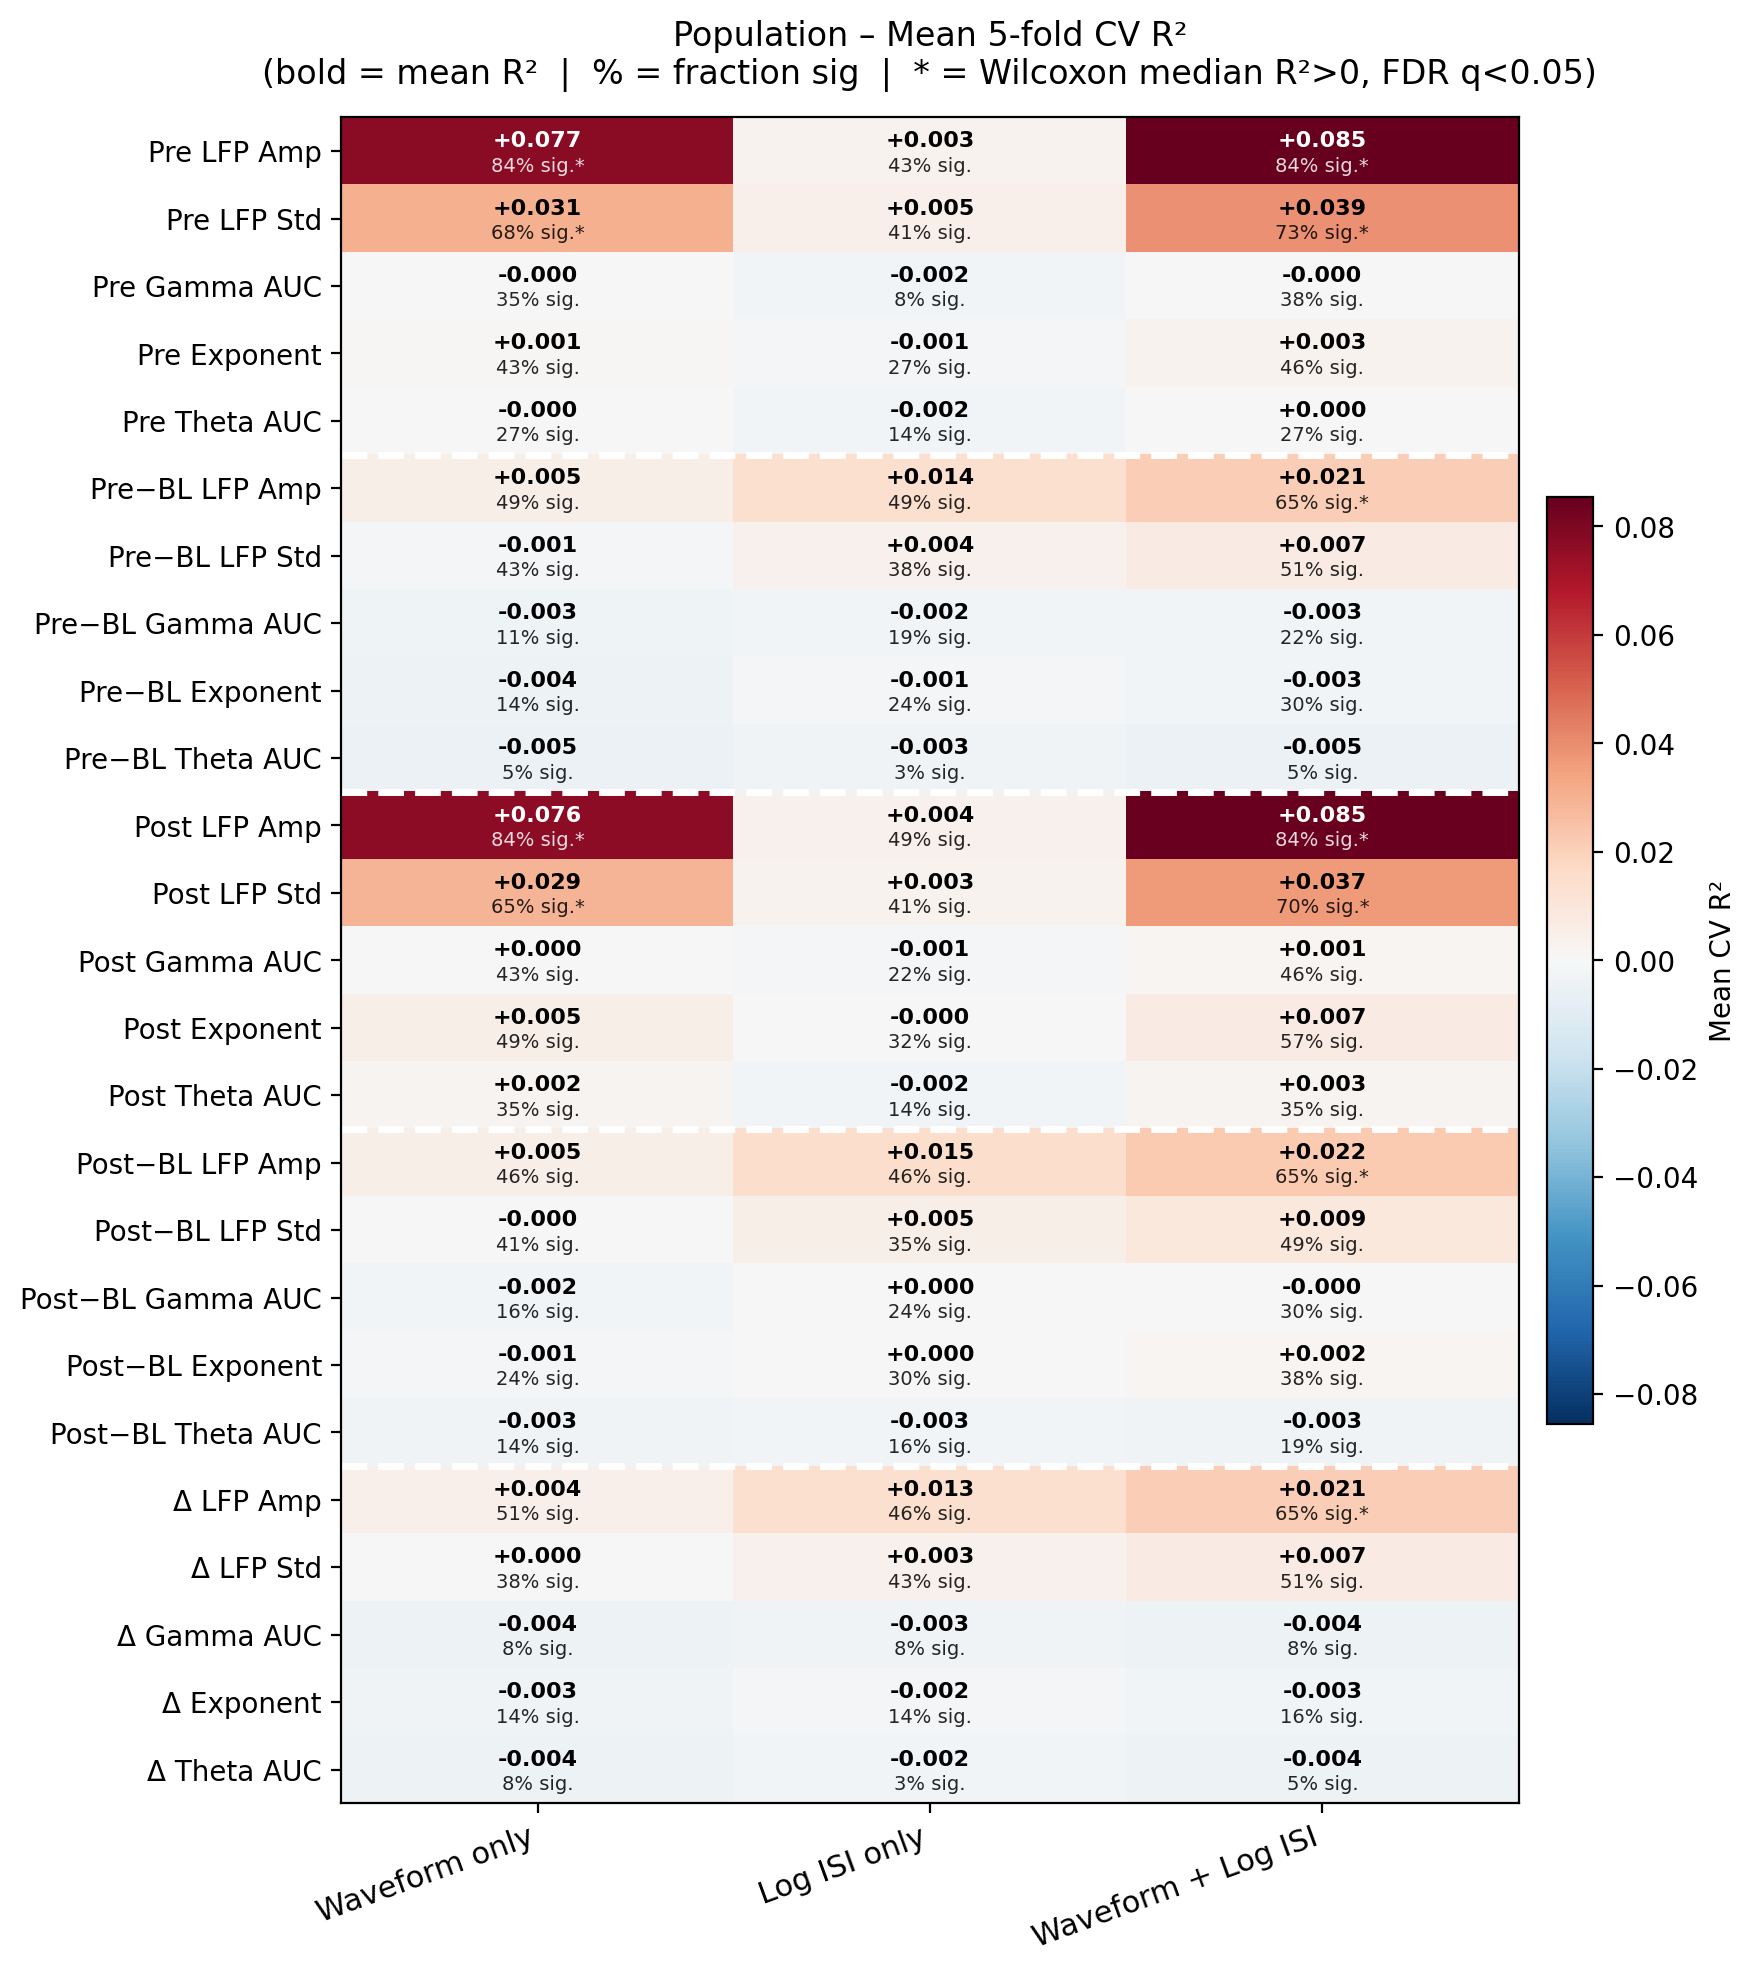

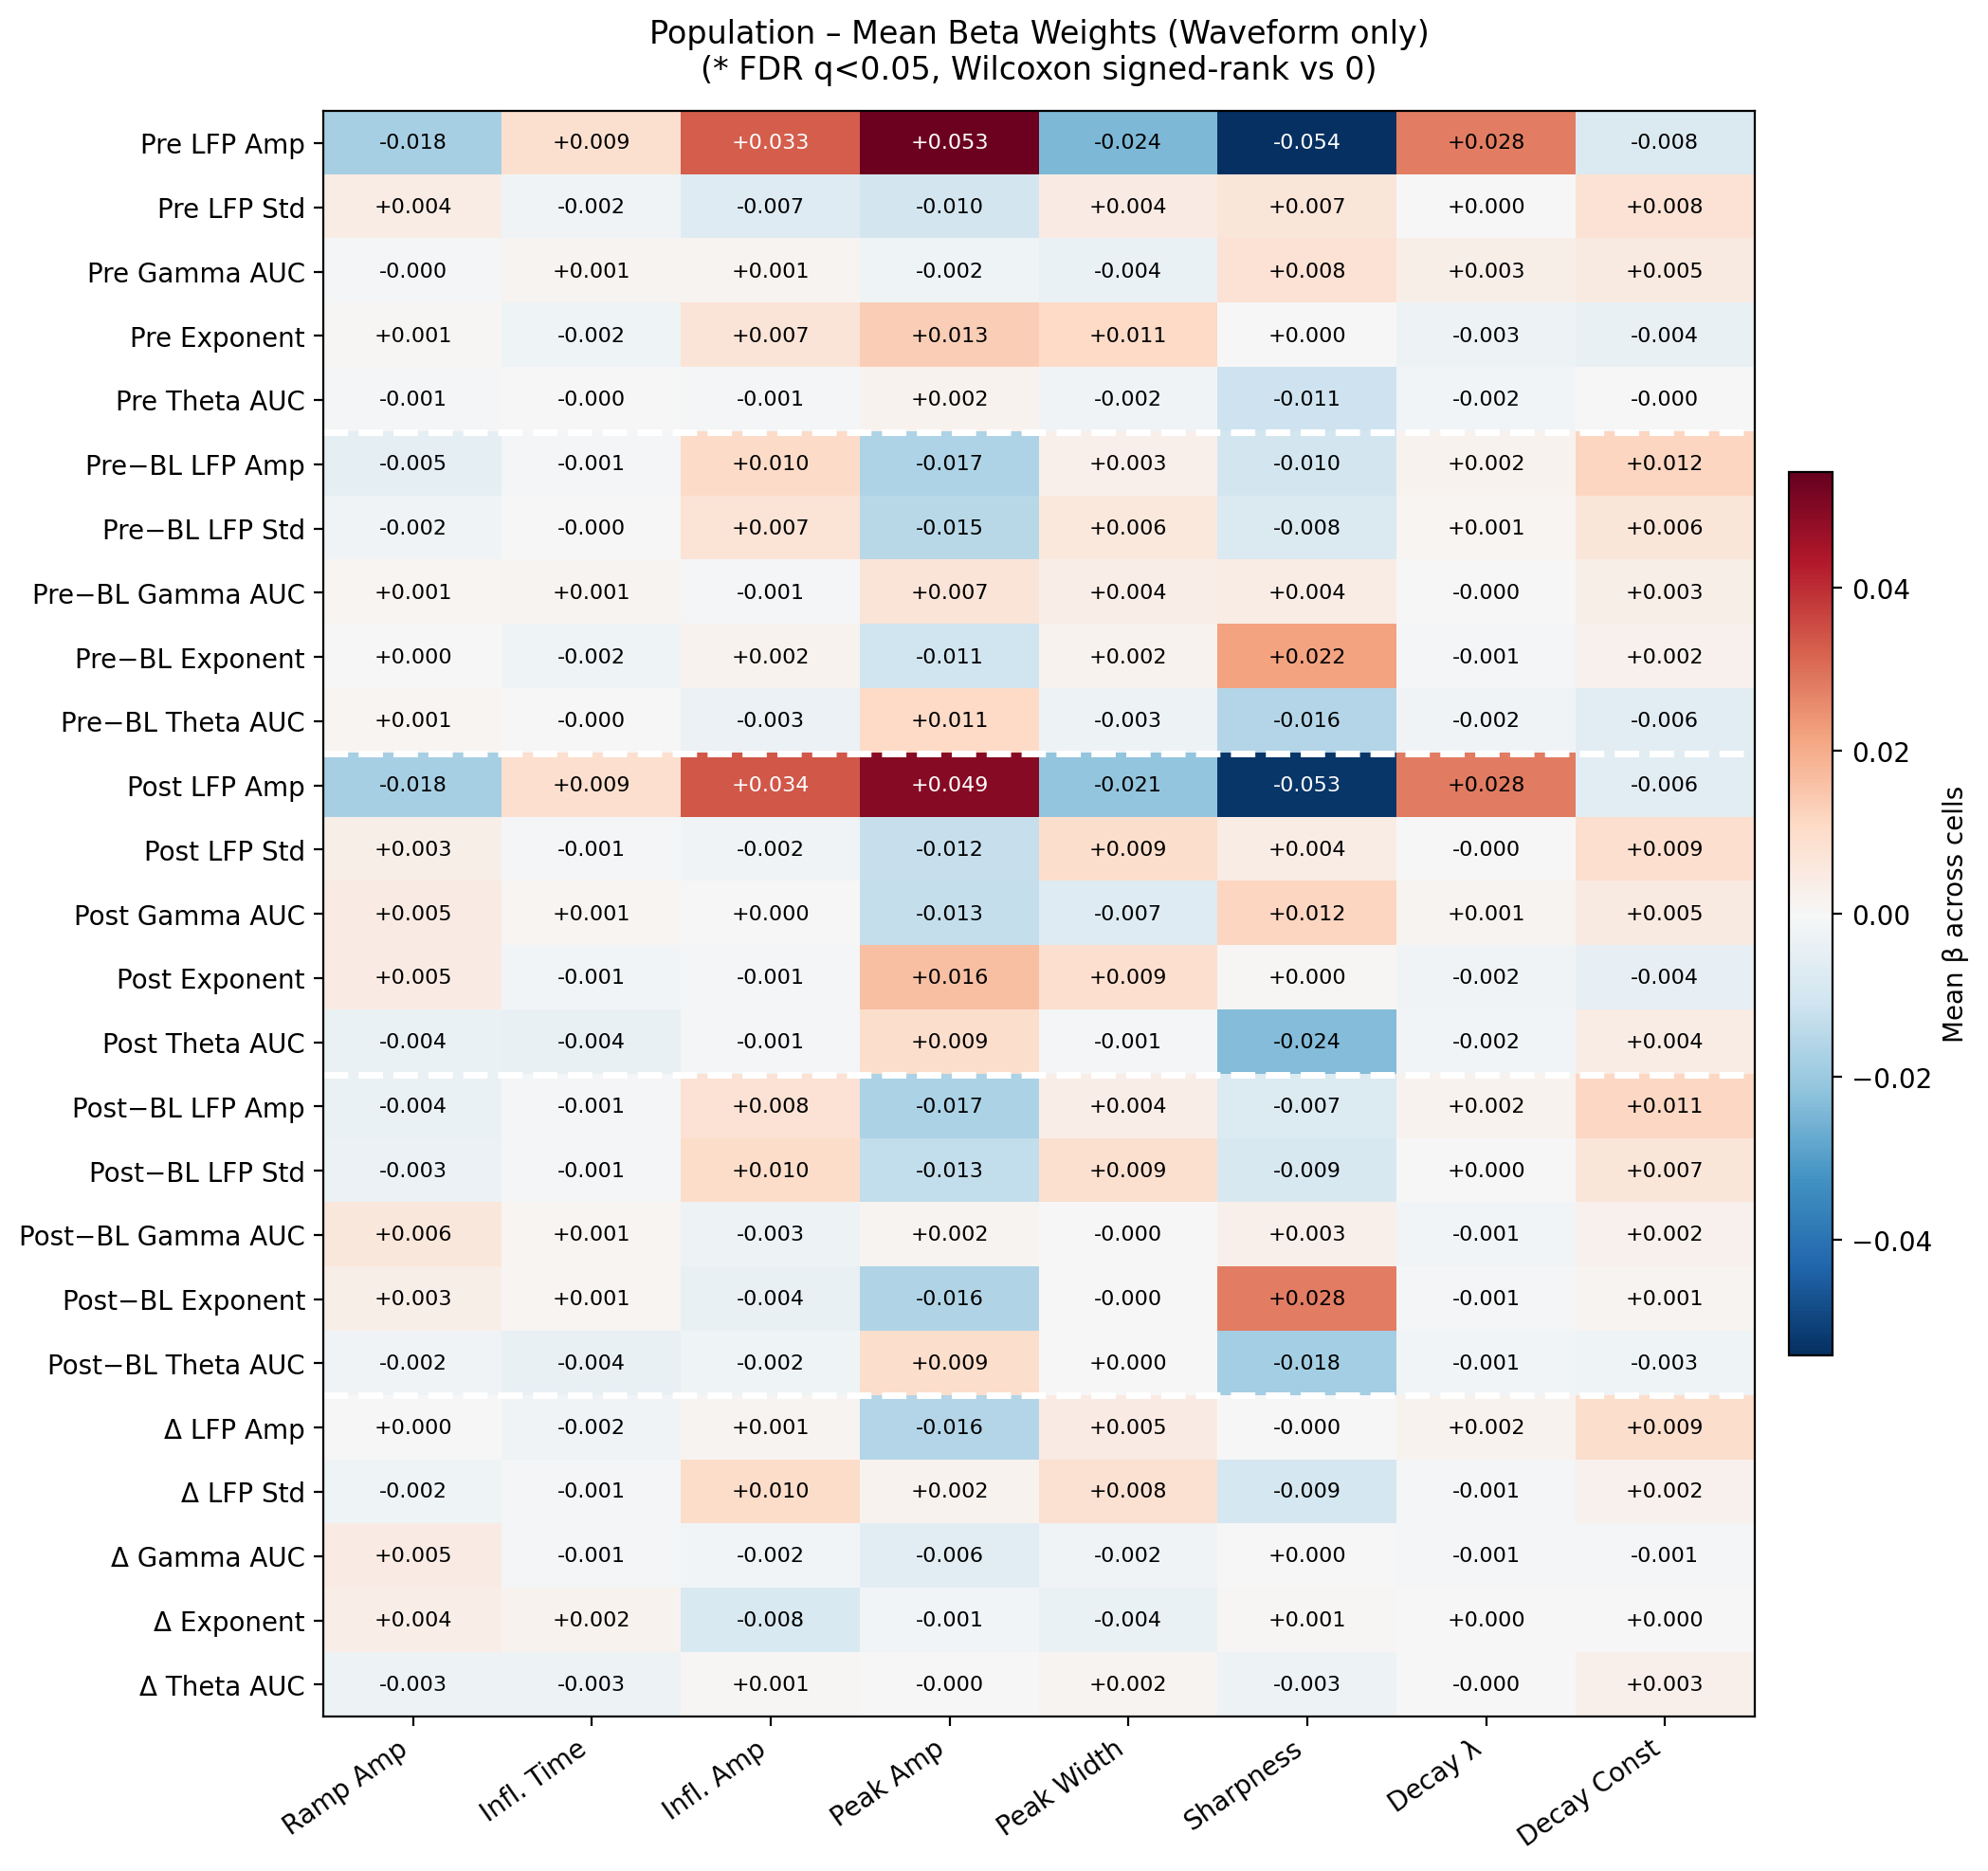

No population-level FDR-significant pairs.


In [7]:
# ── 4. Plots: R² heatmap, beta heatmap, rainclouds ────────────────────────────
mean_r2, frac_sig, mean_beta_mat, sig_beta_mat = plot_population_results(
    r2_pop, sig_pop, beta_pop, df_tests,
    target_names, target_labels, predictor_sets,
    df_frac=df_frac, df_r2=df_r2,
)

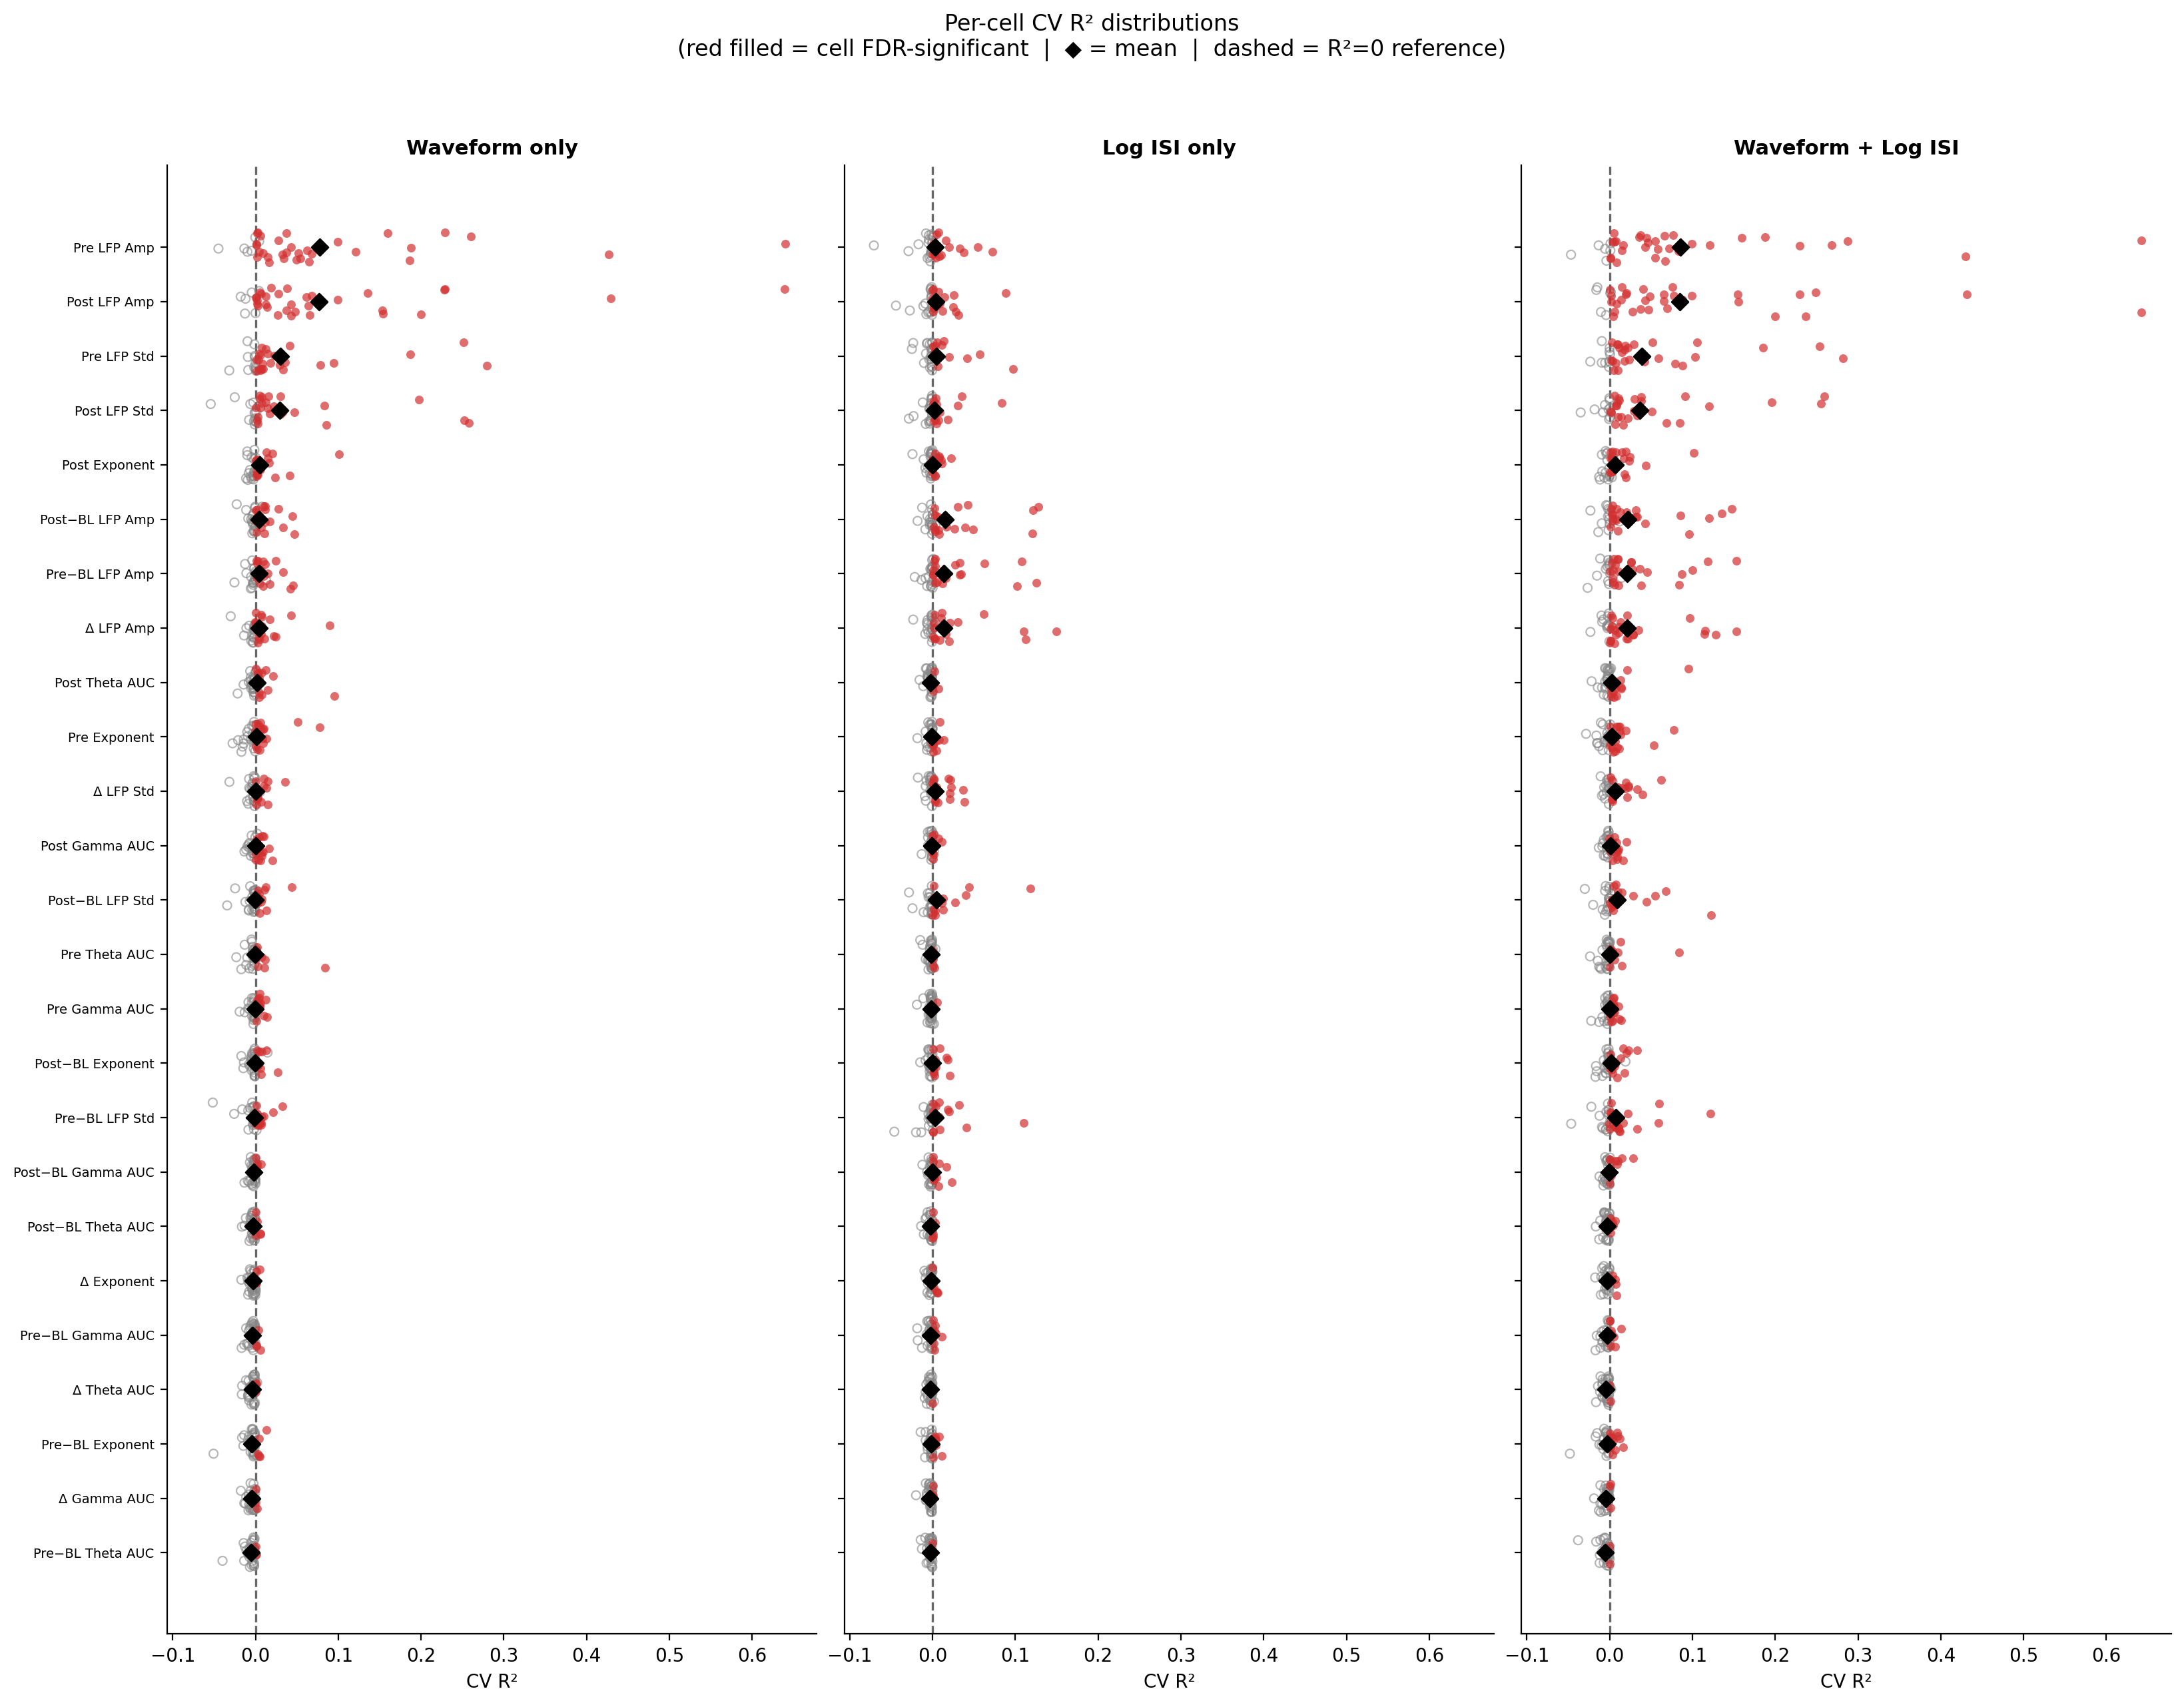

In [8]:
# ── 4b. R² distribution across cells ─────────────────────────────────────────
plot_r2_distributions(
    r2_pop, sig_pop, target_names, target_labels, predictor_sets,
    sort_by='Waveform only', min_r2_line=0.01,
)

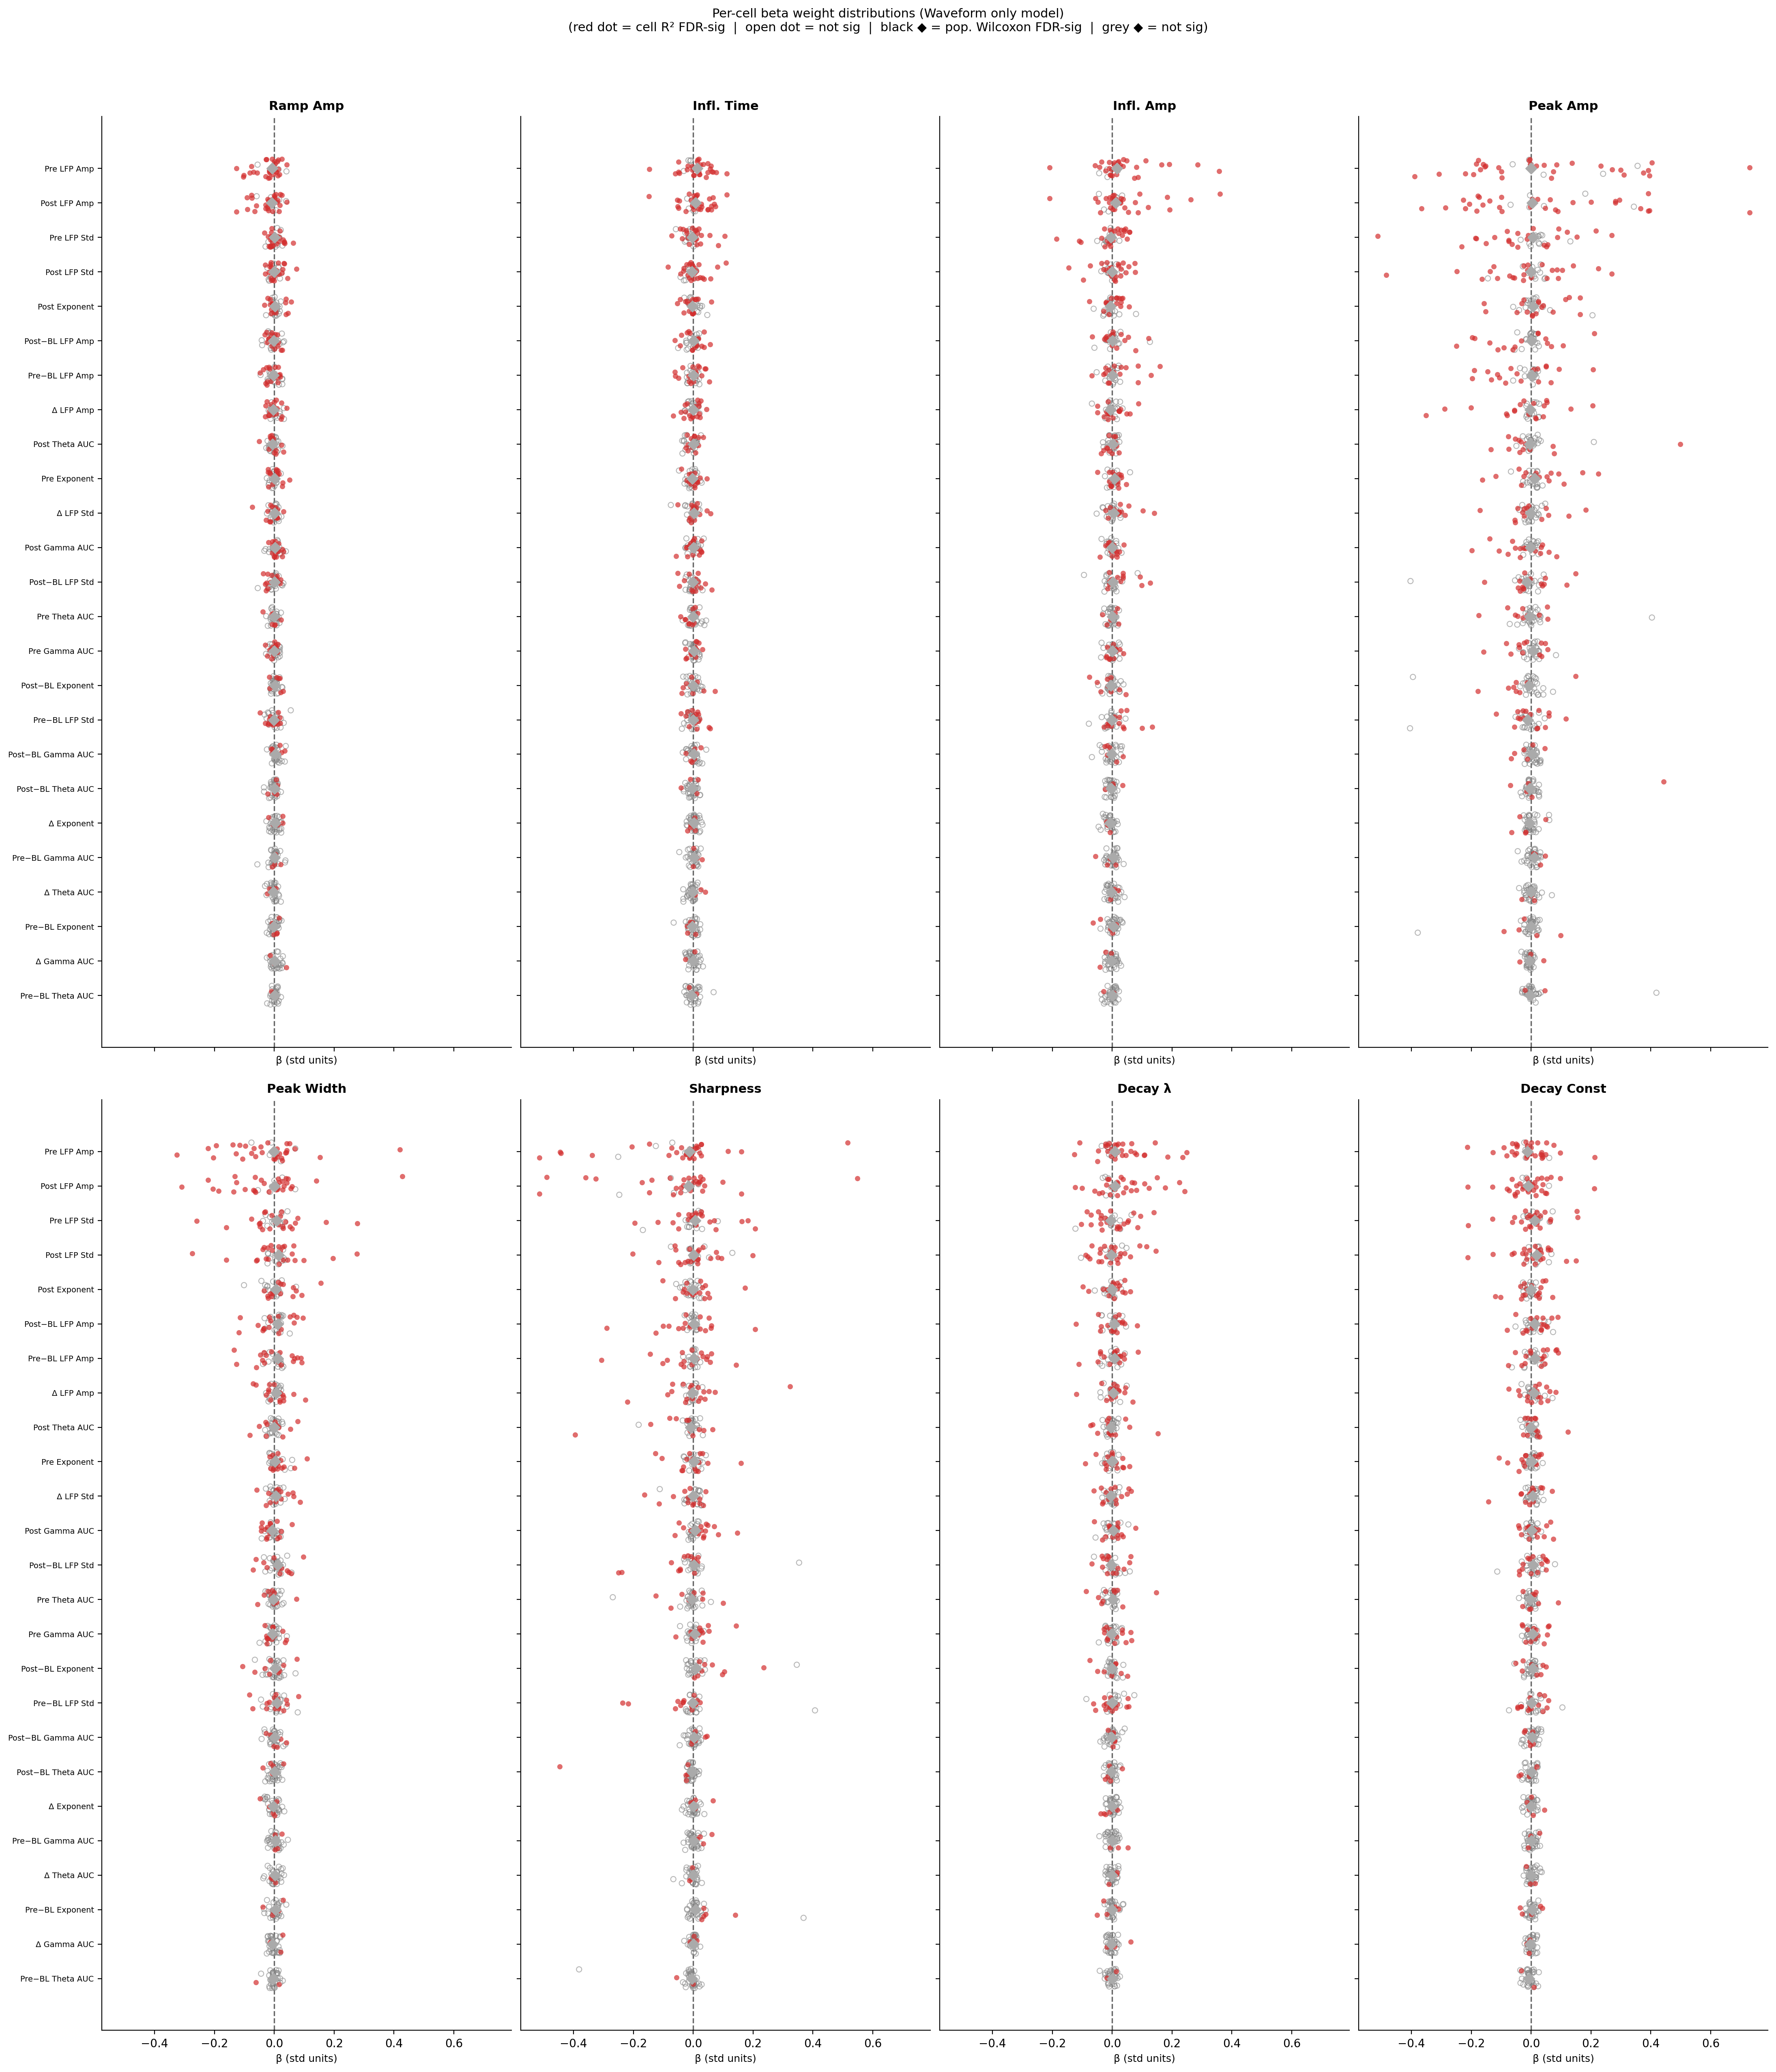

In [9]:
# ── 4c. Beta distributions across cells ──────────────────────────────────────
# One panel per waveform feature; targets sorted by mean R² (same order as R² plot).
# Dot colour: red = that cell's R² model was FDR-significant; grey = not significant.
# Median ◆: black = population Wilcoxon FDR-significant for that target × feature.
plot_beta_distributions(beta_pop, df_tests, target_names, target_labels,
                        sig_pop=sig_pop, sig_pset='Waveform only',
                        sort_by='mean_r2', r2_pop=r2_pop)

## 5. Actual vs predicted scatter (pooled)

Each point is one spike from one cell, z-scored within cell before pooling.  
Only cells with FDR-significant Waveform-only models are included.  
Each colour = one cell.

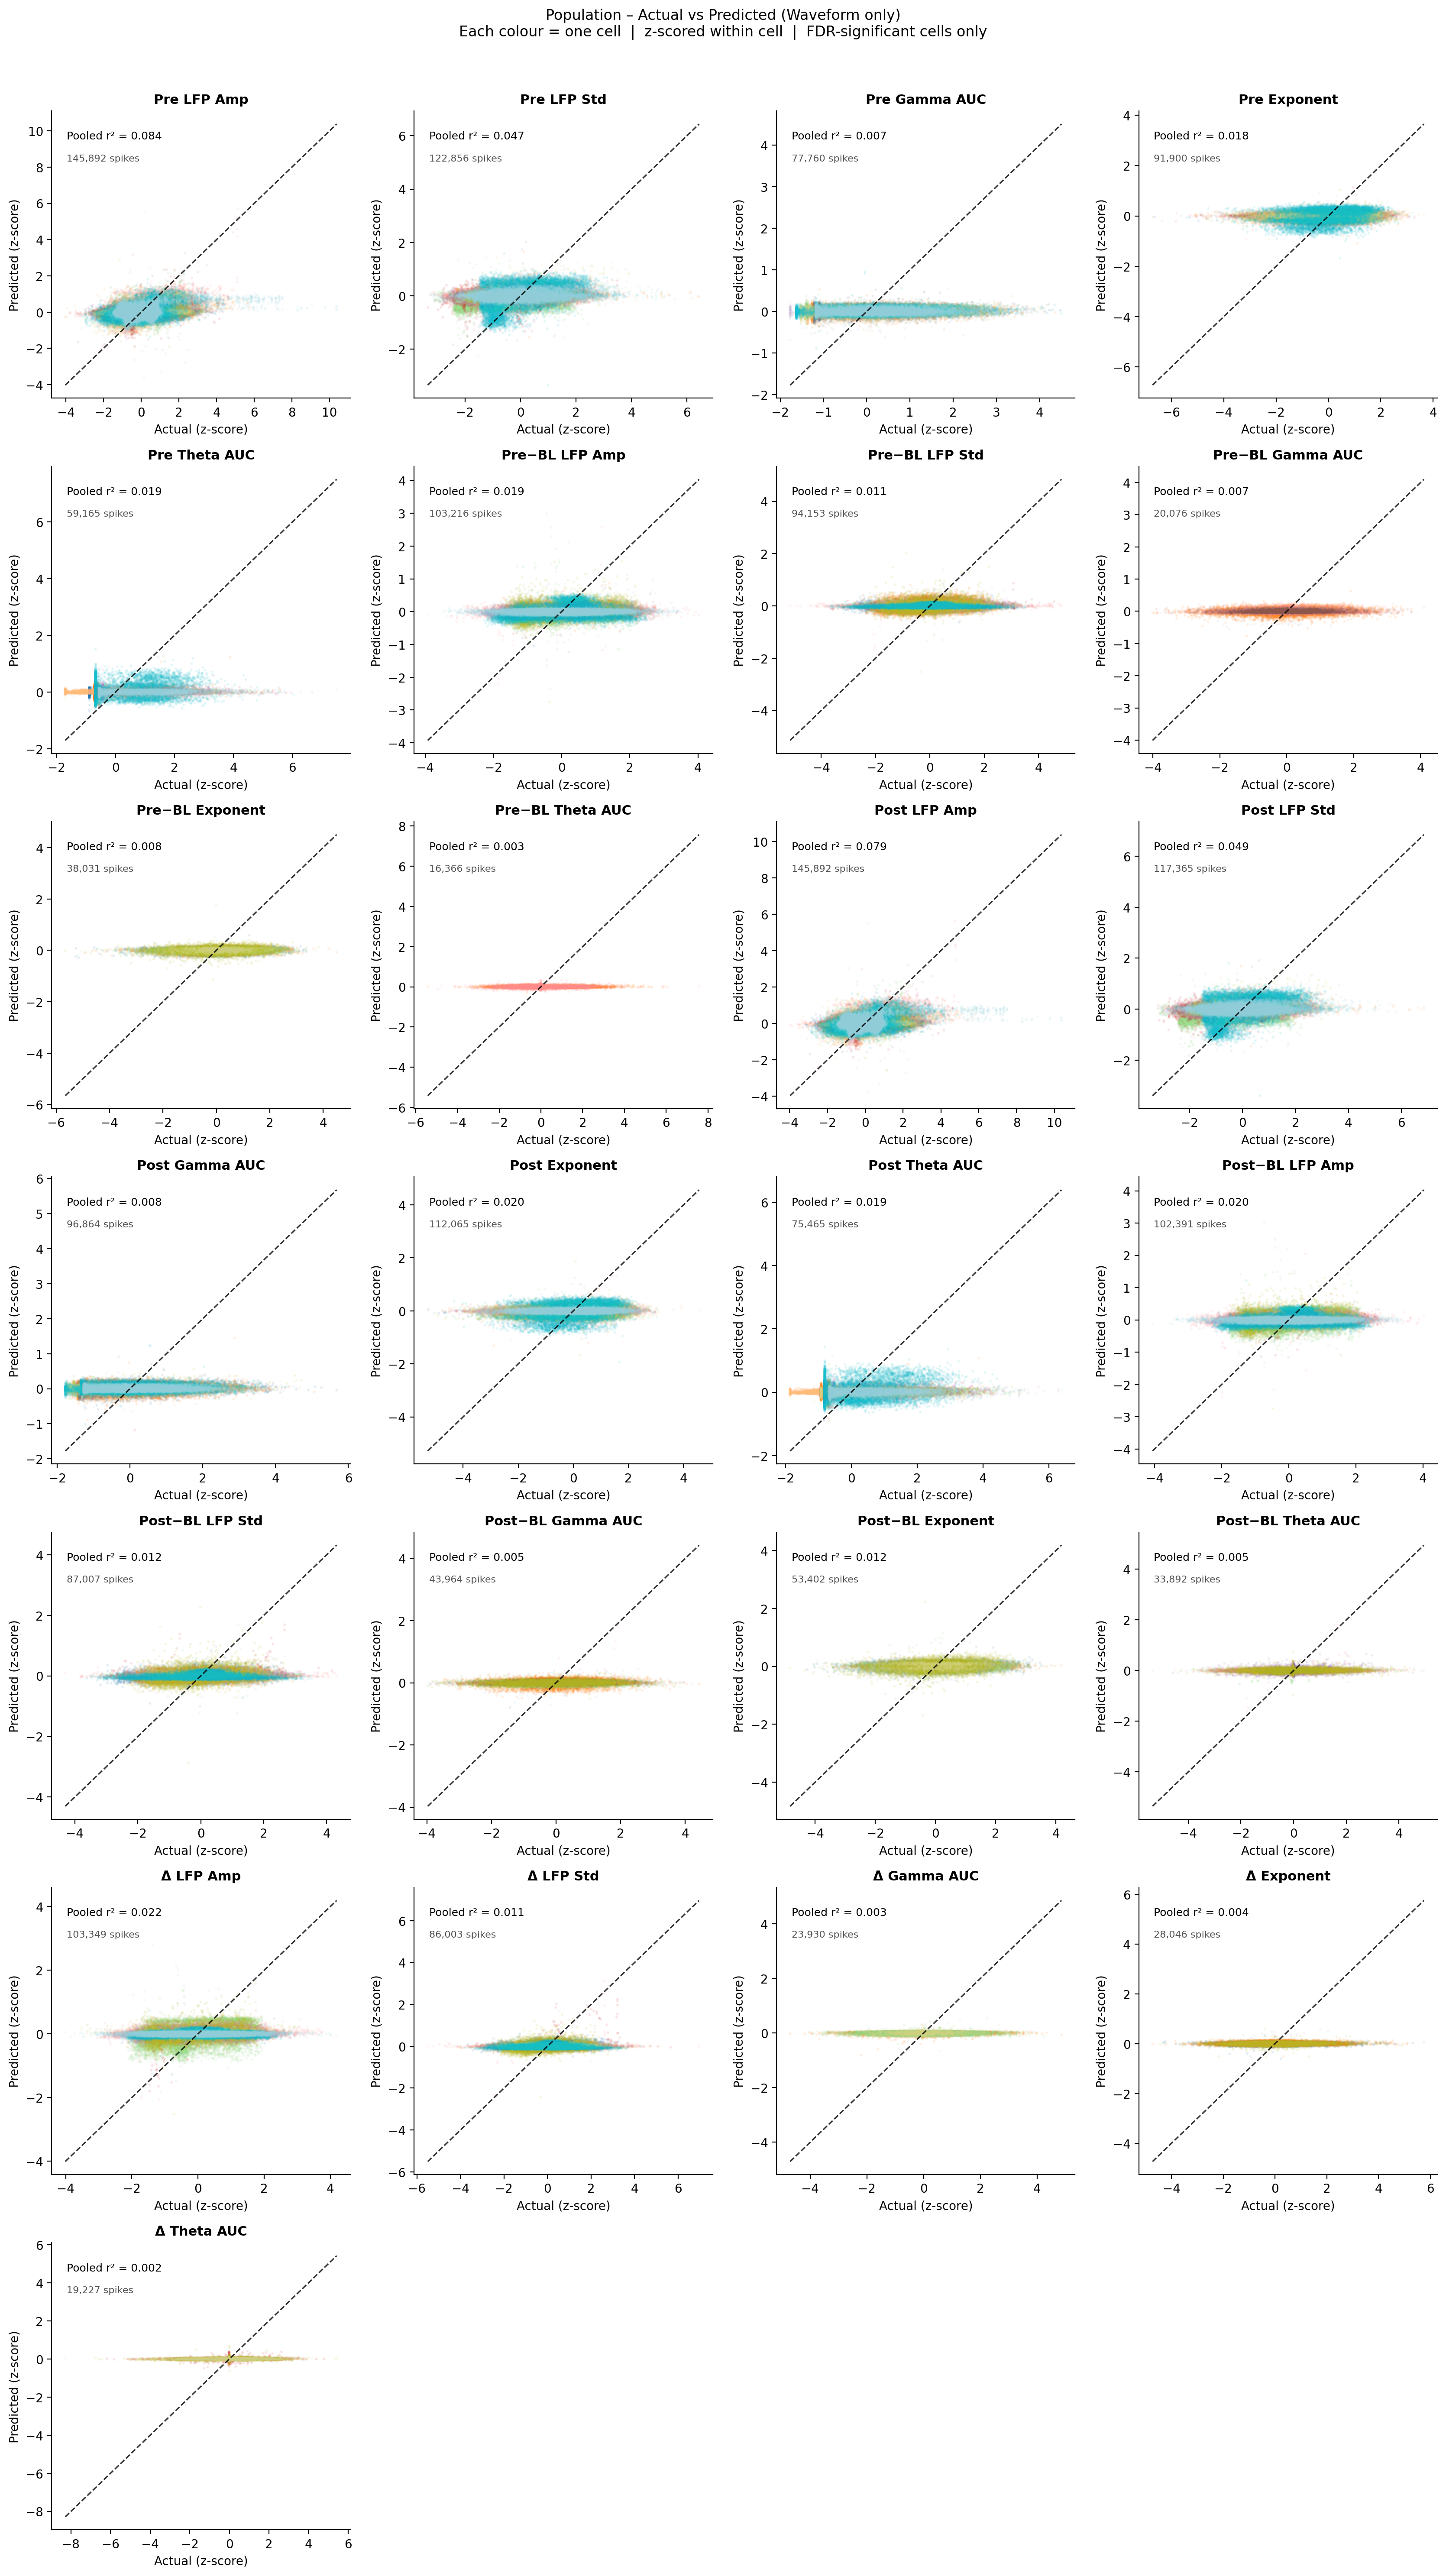

In [10]:
# ── 5. Population scatter (reads from pickles — fast) ────────────────────────
build_population_scatter(all_results, cell_ids, target_names, target_labels)

In [11]:
# ── 6. Save ───────────────────────────────────────────────────────────────────
save_population_results(
    RIDGE_PICKLE_DIR, r2_pop, sig_pop, beta_pop, df_tests,
    mean_r2, frac_sig, mean_beta_mat, sig_beta_mat,
    target_names, target_labels, predictor_sets, cell_ids,
    df_frac=df_frac, df_r2=df_r2,
)

Saved: population_ridge_results.pkl
